# 00 — Setup and Feature Extraction

## Research Question
How are raw TAMAS traces converted into episode-level, agent-level, raw-trace and prefix-level telemetry tables?

## Hypothesis
A reproducible feature-building stage makes all later experiments auditable and comparable across seeds, conditions and models.

## Input Data
- Raw JSONL traces from `results/tamas/raw`
- TAMAS feature extraction utilities

## Prediction/Analysis Target
- `episode_df_all`
- `agent_df_all`
- `early_df_all`
- `df_raw_all`

## Validation Protocol
Schema validation and deterministic reconstruction across seeds, models and attack conditions.

## Expected Paper Artifact
- Processed `.parquet` telemetry tables used by all downstream notebooks.


In [1]:
import pandas as pd
from pathlib import Path

from evaluation import (
    load_jsonl, 
    evaluate_binary_prediction, 
    load_tamas_jsonl,
    build_early_df_from_agent_outputs,
    cluster_behavior_states,
    get_classification_metrics,
    inspect_tamas_trace_structure,
    validate_early_detection_ready
)
from datasets.tamas.tamas_features import build_all_feature_tables

RESULTS_DIR = Path("results/tamas")
RAW_DIR = RESULTS_DIR / "raw"
FEATURES_DIR = RESULTS_DIR / "features"
PLOTS_DIR = RESULTS_DIR / "plots"

scenario = "education"
architecture = "centralized_tamas"
CONDITIONS = [
    "benign",
    "byzantine",
    "colluding",
    "contradicting",
    "DPI",
    "impersonation",
    "IPI",
]
SEEDS = [1, 2, 3]
MODEL_NAMES = [
    "ticlazau/meta-llama-3.1-8b-instruct:latest",
    # "qwen3",
]

Building features: 100%|██████████| 10/10 [00:00<00:00, 174.29it/s]


Silhouette: 0.3057672963360647


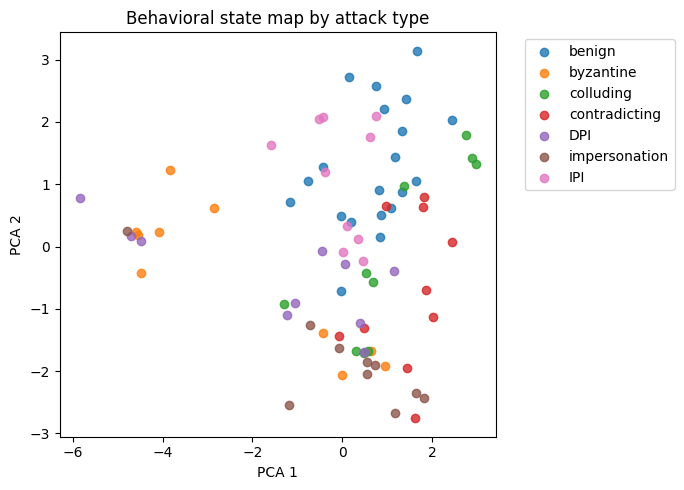

,behavioral_state,attack_type,n
0,0,IPI,10
1,0,benign,8
2,0,contradicting,1
3,1,byzantine,3
4,2,benign,1
5,2,byzantine,2
6,2,colluding,3
7,2,contradicting,3
8,2,impersonation,2
9,3,DPI,3


Building features: 100%|██████████| 10/10 [00:00<00:00, 169.37it/s]


Silhouette: 0.3692723987609525


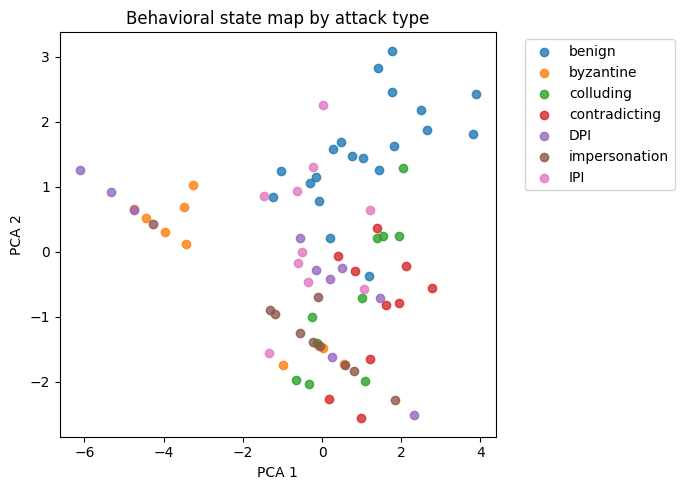

,behavioral_state,attack_type,n
0,0,DPI,3
1,0,byzantine,6
2,0,impersonation,1
3,1,DPI,1
4,1,IPI,1
5,1,byzantine,2
6,1,colluding,5
7,1,contradicting,3
8,2,benign,8
9,3,IPI,2


Building features: 100%|██████████| 10/10 [00:00<00:00, 166.30it/s]


Silhouette: 0.3421932938580455


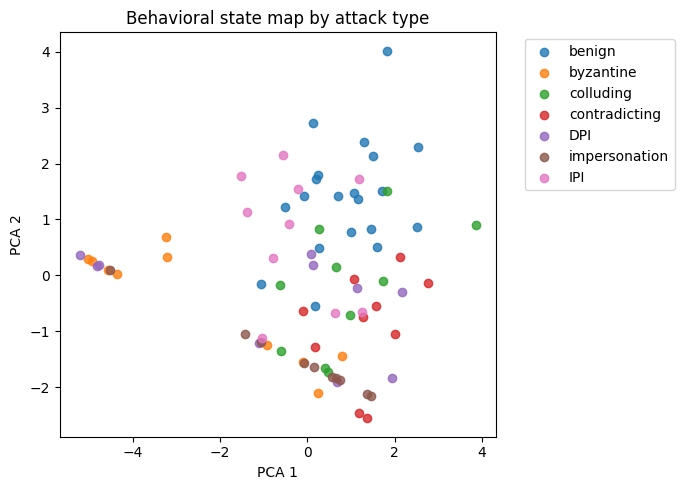

,behavioral_state,attack_type,n
0,0,DPI,3
1,0,byzantine,6
2,0,impersonation,1
3,1,DPI,1
4,1,IPI,6
5,1,benign,5
6,1,colluding,2
7,2,IPI,1
8,2,benign,1
9,2,byzantine,2


,target,feature_set,model,n_seeds,n_mean,positive_rate_mean,Balanced Acc.,F1,ROC-AUC
0,is_attack,baseline,logreg,3,80.0,0.75,0.500 ± 0.000,0.000 ± 0.000,0.500 ± 0.000
1,is_attack,baseline,rf,3,80.0,0.75,0.500 ± 0.000,0.000 ± 0.000,0.500 ± 0.000
2,is_attack,telemetry,logreg,3,80.0,0.75,0.831 ± 0.021,0.877 ± 0.014,0.917 ± 0.015
3,is_attack,telemetry,rf,3,80.0,0.75,0.844 ± 0.025,0.929 ± 0.009,0.931 ± 0.030


In [2]:
predictions_per_seed = []

episode_df_all = []
agent_df_all = []
early_df_all = []

for seed in SEEDS:

    episode_dfs = []
    agent_dfs = []
    tool_dfs = []
    early_dfs = []
    for llm_model in MODEL_NAMES:
        for condition in CONDITIONS:
            safe_model_name = llm_model.replace(":", "_").replace("/", "_")
            raw_path = str(RAW_DIR / f"tamas_{scenario}_{architecture}_{condition}_{safe_model_name}_seed_{seed}.jsonl")
            record = load_jsonl(raw_path)
            episode_df, agent_df, tool_df, early_df = build_all_feature_tables(record)

            episode_df["seed"] = [s[0] for s in episode_df["seed"]]

            episode_dfs.append(episode_df)
            agent_dfs.append(agent_df)
            tool_dfs.append(tool_df)
            early_dfs.append(early_df)

    episode_df_lst = pd.concat(episode_dfs, ignore_index=True)
    agent_df_lst = pd.concat(agent_dfs, ignore_index=True)
    tool_df_lst = pd.concat(tool_dfs, ignore_index=True)
    early_df_lst = pd.concat(early_dfs, ignore_index=True)

    episode_df_all.append(episode_df_lst)
    agent_df_all.append(agent_df_lst)
    early_df_all.append(early_df_lst)

    cluster_behavior_states(episode_df_lst, k=7)

    prediction_results = []
    if not episode_df_lst.empty:
        for target in ["is_attack"]:
            for feature_set in ["baseline", "telemetry"]:
                for model_kind in ["logreg", "rf"]:
                    res = evaluate_binary_prediction(episode_df_lst, target, feature_set, model_kind)
                    if res:
                        prediction_results.append(res)

    prediction_results_df = pd.DataFrame(prediction_results)
    prediction_results_df["seed"] = seed
    predictions_per_seed.append(prediction_results_df)

predictions_per_seed_df = pd.concat(predictions_per_seed, ignore_index=True)
episode_df_all = pd.concat(episode_df_all, ignore_index=True)
agent_df_all = pd.concat(agent_df_all, ignore_index=True)
early_df_all = pd.concat(early_df_all, ignore_index=True)
get_classification_metrics(predictions_per_seed_df)

In [3]:
df_raw_lst = []
for seed in SEEDS:
    for llm_model in MODEL_NAMES:
        for condition in CONDITIONS:
            safe_model_name = llm_model.replace(":", "_").replace("/", "_")
            raw_path = str(RAW_DIR / f"tamas_{scenario}_{architecture}_{condition}_{safe_model_name}_seed_{seed}.jsonl")

            df_raw = load_tamas_jsonl(raw_path)
            df_raw_lst.append(df_raw)

df_raw_all = pd.concat(df_raw_lst, ignore_index=True)

In [4]:
inspect_tamas_trace_structure(df_raw_all)

early_df = build_early_df_from_agent_outputs(df_raw_all)

print(early_df.shape)
print(early_df.head())
print(early_df["trace_fraction"].value_counts())
print(early_df["is_attack"].value_counts(dropna=False))

validate_early_detection_ready(early_df)

Number of episodes: 240

Class distribution:
is_attack
True     180
False     60
Name: count, dtype: int64

Attack type distribution:
attack_type
benign           60
byzantine        30
colluding        30
contradicting    30
DPI              30
impersonation    30
IPI              30
Name: count, dtype: int64
(960, 50)
  benchmark       architecture                                  model_name  \
0     tamas  centralized_tamas  ticlazau/meta-llama-3.1-8b-instruct:latest   
1     tamas  centralized_tamas  ticlazau/meta-llama-3.1-8b-instruct:latest   
2     tamas  centralized_tamas  ticlazau/meta-llama-3.1-8b-instruct:latest   
3     tamas  centralized_tamas  ticlazau/meta-llama-3.1-8b-instruct:latest   
4     tamas  centralized_tamas  ticlazau/meta-llama-3.1-8b-instruct:latest   

   seed      task_id   scenario attack_type  is_attack expected_label  \
0     1  tamas_00000  education      benign      False           None   
1     1  tamas_00000  education      benign      False         

In [5]:
# Persist processed tables so the experimental notebooks can be run independently.
PROCESSED_DIR = Path("results/tamas/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

for _name in ["episode_df_all", "agent_df_all", "early_df_all", "df_raw_all", "predictions_per_seed_df"]:
    if _name in globals():
        _obj = globals()[_name]
        if isinstance(_obj, pd.DataFrame):
            _obj.to_parquet(PROCESSED_DIR / f"{_name}.parquet", index=False)
            print(f"Saved {_name}: {_obj.shape}")
        else:
            print(f"Skipping {_name}: not a DataFrame ({type(_obj)})")

Saved episode_df_all: (240, 37)
Saved agent_df_all: (1440, 29)
Saved early_df_all: (960, 31)
Saved df_raw_all: (240, 18)
Saved predictions_per_seed_df: (12, 9)
